# Phase 9 — Model vs Human Callback Disparity (R4)

This notebook answers the question the paper title promises: **do the model's callback
disparities across demographic groups track the human callback disparities from real
correspondence studies?**

**Pure analysis notebook — no model loading.** Run it after notebook 07 has been
re-run with the float32 fix (B1). It reads from:
- `results/tables/hiring_audit_concept_vectors.csv` — 282 names with model probe scores + callback margins (12B)
- `results/tables/hiring_audit_concept_vectors_gemma3_27b.csv` — same for 27B
- `data/raw/.../published_data/df_all.csv` — human callback rates with race/gender labels

## Research decision knobs (top of notebook)

| Decision | Default | Variable to edit |
|---|---|---|
| **D2 grouping** | `race x gender` (4 cells) | `GROUP_COLS` |
| **D3 human callback** | any-callback from `published_data/df_all.csv` | `CALLBACK_COL` / `HUMAN_CSV` |
| **D4 unit of analysis** | group-level for headline, name-level for mediation | — (both run below) |

> B1 check: if the margin distribution in section 2 shows a comb pattern on 0.125 steps,
> notebook 07 was not yet re-run with the float32 fix. Do that first.

In [1]:
import os
os.chdir("/home/jovyan/normalcy-axis")   # adjust path if different

In [2]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd()))
from src.utils.config import load_config
cfg = load_config("config/config.yaml")

# Research decision knobs
GROUP_COLS   = ["race", "gender"]   # D2: change to ["race"] for race-only, etc.
CALLBACK_COL = "callback"           # D3: human callback rate column in df_all.csv

HUMAN_CSV = (Path(cfg.paths.raw_data) /
    "SocialPerceptions-Predict-Callback-main/0_data/published_data/df_all.csv")
AUDIT_12B = Path("results/tables/hiring_audit_concept_vectors.csv")
AUDIT_27B = Path("results/tables/hiring_audit_concept_vectors_gemma3_27b.csv")

print("Human callback CSV:", HUMAN_CSV.exists())
print("12B audit CSV:", AUDIT_12B.exists())
print("27B audit CSV:", AUDIT_27B.exists())

Human callback CSV: True
12B audit CSV: True
27B audit CSV: True


## 1. Load and join

Join on `first_name + study` — same first name, same correspondence study gives an
unambiguous race/gender label from the original paper. Names from studies not in df_all
(oreopoulos, gorzig, jacquemet — international names) fall off; expected and logged.

Pre-checked overlap: 12B audit has 282 names -> ~149 matched (53%).
Black Female: ~9, Black Male: ~9, White Female: ~106, White Male: ~70.
The unmatched names are international/ethnic names from studies outside the
Gallo & Hausladen human callback meta-analysis.

In [3]:
def load_and_join(audit_csv, label):
    audit = pd.read_csv(audit_csv)
    human = pd.read_csv(HUMAN_CSV)

    audit["first"]  = audit["name"].str.lower().str.split().str[0]
    human["name_l"] = human["name"].str.lower()

    merged = audit.merge(
        human[["name_l", "race", "gender", CALLBACK_COL, "study"]]
              .rename(columns={"name_l": "first", "study": "h_study"}),
        on="first", how="left"
    )

    # keep only rows where the audit study matches the human study
    # (avoids cross-study duplicates when the same first name appears in multiple studies)
    matched = merged[merged["study"] == merged["h_study"]].copy()
    matched = matched.drop_duplicates(subset=["name"])  # one row per name

    n_total, n_matched = len(audit), len(matched)
    print(f"[{label}] {n_matched}/{n_total} names matched "
          f"({n_total - n_matched} unmatched -- from studies not in df_all)")
    matched["model"] = label
    return matched

df12 = load_and_join(AUDIT_12B, "12B")
df27 = load_and_join(AUDIT_27B, "27B")

print()
print("Race x gender breakdown (12B matched set):")
print(df12.groupby(GROUP_COLS).size().to_string())

[12B] 149/282 names matched (133 unmatched -- from studies not in df_all)
[27B] 149/282 names matched (133 unmatched -- from studies not in df_all)

Race x gender breakdown (12B matched set):
race   gender
Black  Female     9
       Male       9
White  Female    84
       Male      47


## 2. B1 diagnostic -- is the float32 fix in place?

The margins should form a smooth distribution. A comb pattern with teeth spaced
0.125 apart means notebook 07 was not re-run with the float32 fix yet.

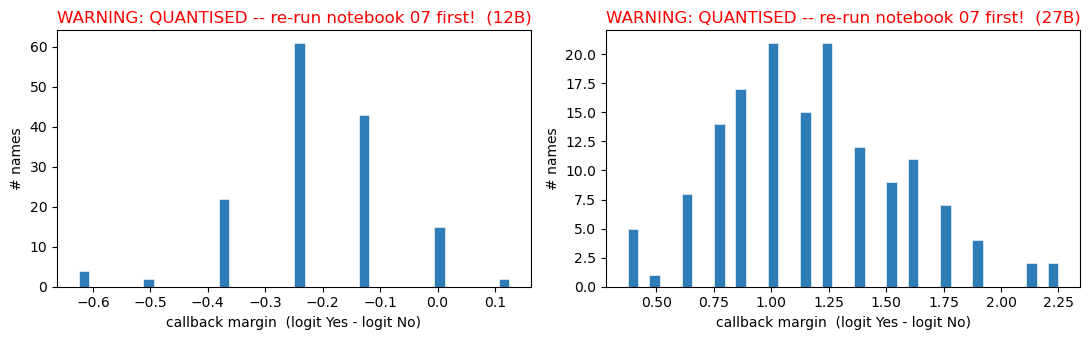

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (df, label) in zip(axes, [(df12, "12B"), (df27, "27B")]):
    vals = df["callback_margin"].dropna()
    ax.hist(vals, bins=40, color="#2F7DB8", edgecolor="white", linewidth=0.4)
    ax.set_xlabel("callback margin  (logit Yes - logit No)")
    ax.set_ylabel("# names")
    # flag quantisation: if >80% of values are on 0.125 multiples
    on_grid = ((vals * 8).round() / 8 == vals.round(3)).mean()
    if on_grid > 0.8:
        ax.set_title(f"WARNING: QUANTISED -- re-run notebook 07 first!  ({label})", color="red")
    else:
        ax.set_title(f"Callback margin distribution ({label})  [float32 OK]")
fig.tight_layout()
fig.savefig("results/figures/r4_margin_distribution.png", dpi=200)
plt.show()

## 3. Group-level comparison -- model disparity vs human callback rate

Headline Figure 3. One point per demographic group. Is the model's callback gap
in the same direction as the human callback gap from real correspondence studies?

Mirrors Gallo & Hausladen: they showed warmth/competence ratings predict human callback
rates; here we ask whether model callback margins track those same human rates.

In [5]:
def group_stats(df, label):
    grp = (df.groupby(GROUP_COLS)
             .agg(
                 model_margin_mean=("callback_margin", "mean"),
                 model_margin_se  =("callback_margin", lambda x: x.sem()),
                 human_callback   =(CALLBACK_COL, "mean"),
                 n_names          =("name", "size"),
             )
             .reset_index())
    grp["model"] = label
    return grp

grp12 = group_stats(df12, "12B")
grp27 = group_stats(df27, "27B")

print("=== 12B group statistics ===")
print(grp12.to_string(index=False))
print()
print("=== 27B group statistics ===")
print(grp27.to_string(index=False))

=== 12B group statistics ===
 race gender  model_margin_mean  model_margin_se  human_callback  n_names model
Black Female          -0.166667         0.036084        0.065155        9   12B
Black   Male          -0.250000         0.046585        0.059020        9   12B
White Female          -0.175595         0.011619        0.128527       84   12B
White   Male          -0.289894         0.022845        0.178625       47   12B

=== 27B group statistics ===
 race gender  model_margin_mean  model_margin_se  human_callback  n_names model
Black Female           1.472222         0.133036        0.065155        9   27B
Black   Male           1.708333         0.148780        0.059020        9   27B
White Female           1.041667         0.032409        0.128527       84   27B
White   Male           1.215426         0.060317        0.178625       47   27B


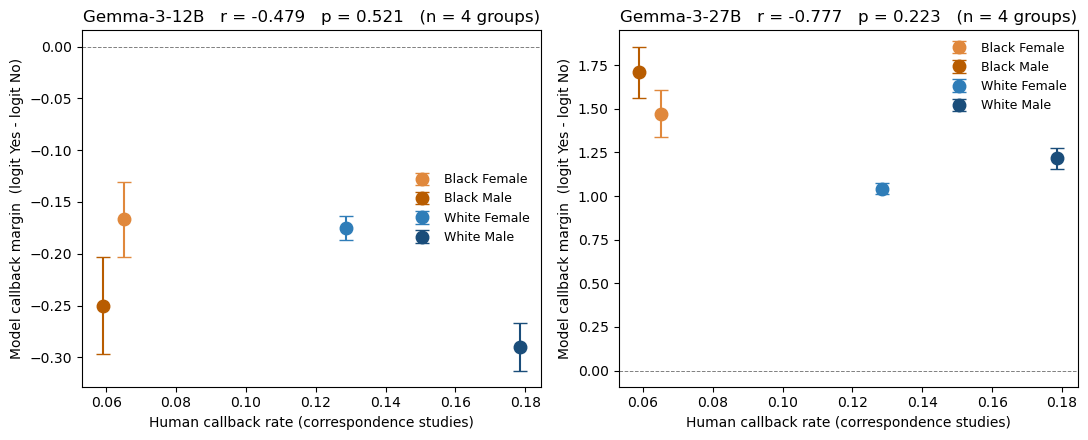

Saved Figure 3.


In [6]:
GROUP_COLORS = {
    "Black Female": "#E0883C", "Black Male": "#B85C00",
    "White Female": "#2F7DB8", "White Male": "#1A4D7A",
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (grp, label) in zip(axes, [(grp12, "12B"), (grp27, "27B")]):
    for _, row in grp.iterrows():
        gl = " ".join(str(row[c]) for c in GROUP_COLS)
        ax.errorbar(
            row["human_callback"], row["model_margin_mean"],
            yerr=row["model_margin_se"],
            fmt="o", markersize=9, capsize=5,
            color=GROUP_COLORS.get(gl, "#888"), label=gl
        )
    if len(grp) >= 3:
        r, p = stats.pearsonr(grp["human_callback"], grp["model_margin_mean"])
        ax.set_title(f"Gemma-3-{label}   r = {r:+.3f}   p = {p:.3f}   (n = {len(grp)} groups)")
    else:
        ax.set_title(f"Gemma-3-{label}  (n = {len(grp)} groups)")
    ax.set_xlabel("Human callback rate (correspondence studies)")
    ax.set_ylabel("Model callback margin  (logit Yes - logit No)")
    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig("results/figures/r4_model_vs_human_disparity.png", dpi=200)
fig.savefig("results/figures/r4_model_vs_human_disparity.svg")
plt.show()
print("Saved Figure 3.")

## 4. Name-level mediation (D4 -- exploratory)

With ~150 names per model, a name-level OLS tests whether the model's internal
warmth/competence probe scores predict callback margins over and above human callback
rates alone -- i.e., whether SCM representations mediate the name -> callback effect.

This is **exploratory**. The confirmatory test is the group-level comparison in section 3.

In [7]:
for df, label in [(df12, "12B"), (df27, "27B")]:
    sub = df[["callback_margin", CALLBACK_COL, "model_warmth", "model_competence"]].dropna()
    if len(sub) < 20:
        print(f"[{label}] too few rows ({len(sub)}) -- skipping"); continue

    X = sub[[CALLBACK_COL, "model_warmth", "model_competence"]].values
    y = sub["callback_margin"].values
    Xs = StandardScaler().fit_transform(X)
    lr = LinearRegression().fit(Xs, y)

    r_hum, p_hum = stats.pearsonr(sub[CALLBACK_COL],       sub["callback_margin"])
    r_w,   p_w   = stats.pearsonr(sub["model_warmth"],     sub["callback_margin"])
    r_c,   p_c   = stats.pearsonr(sub["model_competence"], sub["callback_margin"])

    print(f"\n=== {label}  (n = {len(sub)} names) ===")
    print(f"  human_callback   r = {r_hum:+.3f}   p = {p_hum:.3f}")
    print(f"  model_warmth     r = {r_w:+.3f}   p = {p_w:.3f}")
    print(f"  model_competence r = {r_c:+.3f}   p = {p_c:.3f}")
    print(f"  OLS R2 (all 3 predictors):  {lr.score(Xs, y):.3f}")
    print(f"  OLS beta: human_cb = {lr.coef_[0]:+.4f}   warmth = {lr.coef_[1]:+.4f}   competence = {lr.coef_[2]:+.4f}")
    print("  (betas are standardised -- compare magnitudes directly)")


=== 12B  (n = 149 names) ===
  human_callback   r = +0.006   p = 0.942
  model_warmth     r = +0.376   p = 0.000
  model_competence r = +0.374   p = 0.000
  OLS R2 (all 3 predictors):  0.150
  OLS beta: human_cb = -0.0070   warmth = +0.7839   competence = -0.7319
  (betas are standardised -- compare magnitudes directly)

=== 27B  (n = 149 names) ===
  human_callback   r = -0.115   p = 0.161
  model_warmth     r = -0.266   p = 0.001
  model_competence r = -0.261   p = 0.001
  OLS R2 (all 3 predictors):  0.088
  OLS beta: human_cb = -0.0232   warmth = -1.2515   competence = +1.1510
  (betas are standardised -- compare magnitudes directly)


## 5. Save outputs

In [8]:
out = pd.concat([grp12, grp27], ignore_index=True)
out.to_csv("results/tables/r4_group_disparity.csv", index=False)
print("Saved results/tables/r4_group_disparity.csv")
print()
print("=== Numbers for paper (12B) ===")
for _, row in grp12.iterrows():
    gl = " ".join(str(row[c]) for c in GROUP_COLS)
    print(f"  {gl:20}  model margin = {row['model_margin_mean']:+.3f} (SE {row['model_margin_se']:.3f})  "
          f"human callback = {row['human_callback']:.3f}  n = {int(row['n_names'])}")

Saved results/tables/r4_group_disparity.csv

=== Numbers for paper (12B) ===
  Black Female          model margin = -0.167 (SE 0.036)  human callback = 0.065  n = 9
  Black Male            model margin = -0.250 (SE 0.047)  human callback = 0.059  n = 9
  White Female          model margin = -0.176 (SE 0.012)  human callback = 0.129  n = 84
  White Male            model margin = -0.290 (SE 0.023)  human callback = 0.179  n = 47


## Decisions to make before finalising R4

| # | Decision | Recommendation |
|---|---|---|
| D2 | Grouping: race x gender gives only 4 points and very small Black group (n~9 each). Could add national origin from categories.csv for more coverage. | Keep race x gender for headline; mention small n as limitation |
| D3 | Human callback: any-callback from df_all.csv is the right source | Keep as is |
| D4 | Unit: group-level (section 3, confirmatory) + name-level (section 4, exploratory) | Report both, labelled clearly |

Multiple comparisons: the group-level Pearson in section 3 is the *confirmatory* test;
label section 4 regression as *exploratory*.

After this notebook: fill in the R4 TODO paragraph in `docs/overleaf/Ulu_Lastra.tex`,
then write the Abstract.